<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

# Paso 1

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

In [2]:
df_games = pd.read_csv('games.csv')

In [3]:
df_games.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


# Paso 2

## 2.1 reemplazar nombres de columnas

In [5]:
#ahora sigue cambiar el nombre de las columnas para tener un formato correcto en todas 

df_games.columns = df_games.columns.str.lower()#cambie las columnas con un .lower para homologar y trabajar mas sencillo el código al filtrar o llamar columnas
df_games.columns


Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

## 2.2 conversion de datos

In [6]:
df_games['year_of_release'] = df_games['year_of_release'].astype('Int64')#venia con valores ausentes y lo marcaba como float pero es el año y lo cambie a int para que sea correct
df_games['user_score'] = df_games['user_score'].replace('tbd', np.nan)#detecte que al cambiarlo a float me daba error porque tenía un valor que cambie a NaN para que pudiera ser float64
#los quite porque al ser por determinar son juegos que tal vez no tenian información cuando se creo el dataset y si se quedan como texto pueden impedir operaciónes matematicas
df_games['user_score'] = df_games['user_score'].astype(float) #lo cambie a float despues de ver el .unique que son valores con punto decimal y viendo lo anterior
#borré mis validaciones previas de info y .unique para dejar mi código mas limpio pero si las hice. 


df_games.info()
df_games.isna().sum().sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


user_score         9125
critic_score       8578
rating             6766
year_of_release     269
name                  2
genre                 2
platform              0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
dtype: int64

En el caso de los valores ausentes me pude dar cuenta que los tenía en 6 de las 10 columnas de mi df en donde los mas notables los tuve en 'year_of_release', en 'critic_score', tambien en user_score y rating y decidi dejarlos así para evitar sesgos en mis resultados ya que desde mi punto de vista el año de lanzamiento no puede ser estimado sin equivocarse o al azar, la puntuación critica y puntuaciones de usuario tambien no se pueden adivinar ya que son de manera individual y ademas mas de la mitad en ambos casos tienen valores nulos lo cual si me generaria un sesgo importante en mi analisis. Por último tenemos el rating que tambien es información que no puedo falsear o algo que yo pueda suponer, entonces al cambiarlos por la media mediana o moda introduciria sesgos en los resultados por lo cual considero mas seguro dejarlos como NaN.

In [7]:
df_games['total_sales'] = (
df_games['na_sales'] +
df_games['eu_sales'] +
df_games['jp_sales'] +
df_games['other_sales']
)

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Hiciste un buen trabajo al cambiar los nombres de las columnas, sus tipos de datos y reemplazar los valores ausentes
</div>


# Paso 3 

## 3.1 Cuantos juegos fueron lanzados en diferentes años

In [8]:
games_by_year= df_games['year_of_release'].value_counts().sort_index()

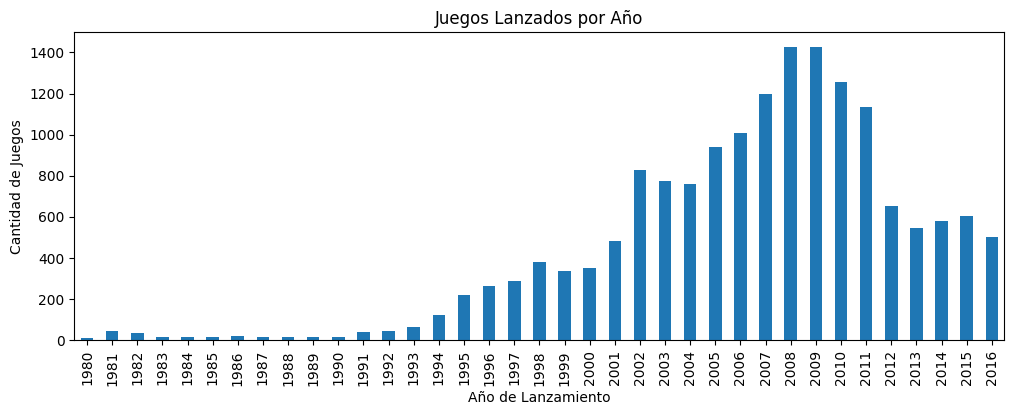

In [9]:


games_by_year.plot(kind='bar',figsize=(12,4))
plt.title('Juegos Lanzados por Año')
plt.ylabel('Cantidad de Juegos')
plt.xlabel('Año de Lanzamiento')
plt.show()



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>

Buena manera de presentar los datos, podemos ver claramente la tendencia de los videojuegos con un incremento constante en años anteriores que ha empezado a ir en declive en los últimos años
</div>


Al observa el gráfico anterior nos damos cuenta que antes del año 2000 y tenemos el pico máximo entr los años 2005 y 2011 especificamente en 2008 y 2009 podemos oservar que 
fueron los dos mejores años de producción y ya despues de 2012 comenzó a disminuir significativamente. 
Entonces se puede concluir con está grafica de barras que los periodos donde se tuvo mayor exito son del 2000 al 2015 ya que como nos dicen el 2016 está incompleto y ademas puedo decir que de los 80 a 90s aunque nos puestrán un historico no son relevantes para modelar una tendencia ni para plantear una campaña en 2017.


## 3.2 variacion de ventas entre plataformas

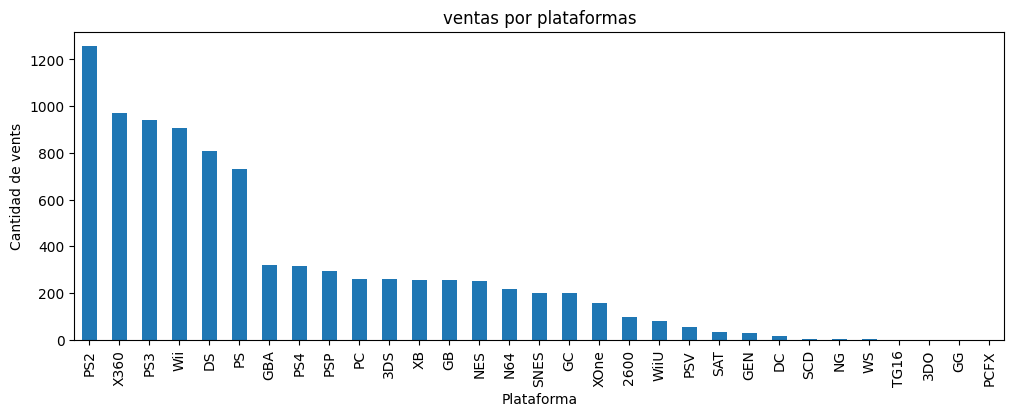

In [10]:


platform_sales = df_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
platform_sales


platform_sales.plot(kind='bar',figsize=(12,4))
plt.title('ventas por plataformas')
plt.ylabel('Cantidad de vents')
plt.xlabel('Plataforma')
plt.show()



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Gracias a la gráfica podemos ver como las primeras plataformas tienen una diferencia bastante considerable respecto a las otras plataformas
</div>


tomando en cuenta el gráfico anterior puedo determinar que hay una gran diferencia entre las plataformas que
vendieron mas y menos donde podemos ver las 5 primeras o las top 5 y a partir de gba baja drásticamente

In [11]:
top_platforms = platform_sales.head(5).index
top_platforms

Index(['PS2', 'X360', 'PS3', 'Wii', 'DS'], dtype='object', name='platform')


Aquí nos podemos dar cuenta que los mejores 5 juegos fueron claramente los de ps2 x360 ps3 wii y DS

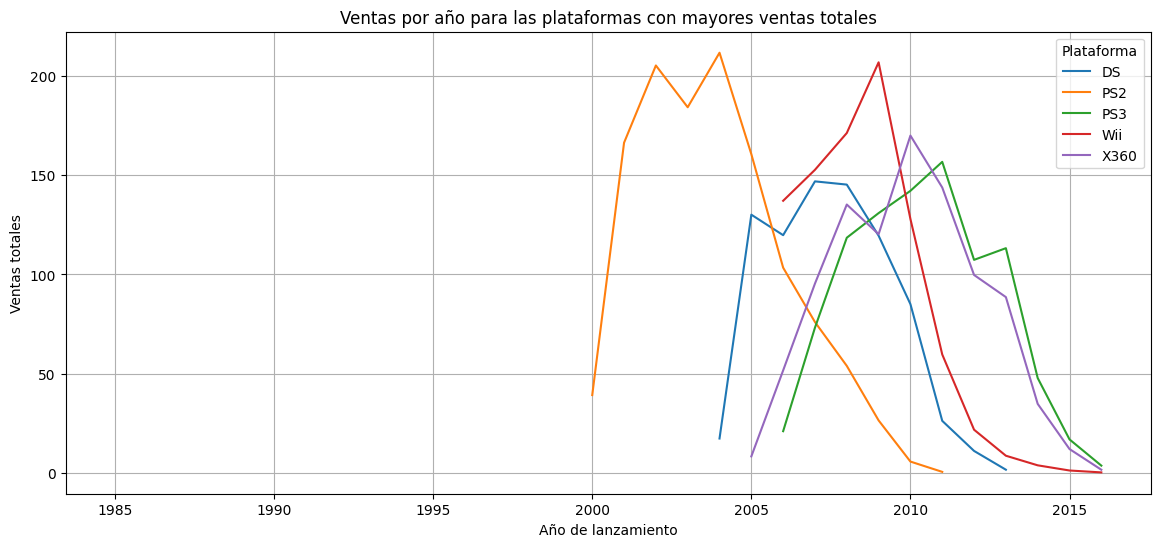

In [12]:

df_top = df_games[df_games['platform'].isin(top_platforms)]

sales_by_year = df_top.groupby(['year_of_release','platform'])['total_sales'].sum().unstack()
sales_by_year.plot(figsize=(14,6))

plt.title('Ventas por año para las plataformas con mayores ventas totales')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Ventas totales')
plt.legend(title='Plataforma')
plt.grid(True) #ESTE LO PONGO PARA VER DE MEJOR MANERA DONDE VAN PUNTUANDO LAS LINEAS
plt.show()



Al analizar la evolución de las ventas por plataforma, se observa que cada una sigue un ciclo similar: después de su lanzamiento, tardan alrededor de 1 a 2 años en ganar fuerza, alcanzan un periodo de popularidad de varios años, y posteriormente comienzan a disminuir sus ventas. Una vez que una plataforma entra en declive, sus ventas caen rápidamente, y normalmente desaparecen del mercado en un periodo de aproximadamente 2 a 3 años.


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Buena manera de mostrar los datos, gracias a la gráfica podemos observar el ciclo de vida de cada una de las plataformas

Recomiendo filtrar los datos, ya que antes del año 2000 no tenemos información relevante que mostrar
</div>


## 3.3 variacion de ventas entre plataformas

Para el siguiente punto (3.3) considero que debo tomar los datos a partir del año 2010, ya que los años anteriores incluyen muchas plataformas que ya desaparecieron y no representan el comportamiento actual del mercado. Utilizar datos viejos podría distorsionar las tendencias reales y afectar la construcción del modelo para 2017. A partir de 2010 se concentran las plataformas que siguen activas o relevantes en ese periodo, por lo que este rango es el más adecuado para el análisis.

## 3.4 trabajar con los datos relevantes 

En este paso decidí filtrar mi dataset utilizando solo las plataformas que siguieron a partir del 2010

In [13]:
df_recent = df_games[df_games['year_of_release'] >= 2010]

In [14]:

plat_sales = df_recent.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
plat_sales


platform
PS3     587.74
X360    550.41
PS4     314.14
3DS     257.81
Wii     222.97
XOne    159.32
DS      123.75
PC      121.96
WiiU     82.19
PSP      64.05
PSV      53.81
PS2       6.09
Name: total_sales, dtype: float64

## 3.5 trabajar con los datos relevantes 

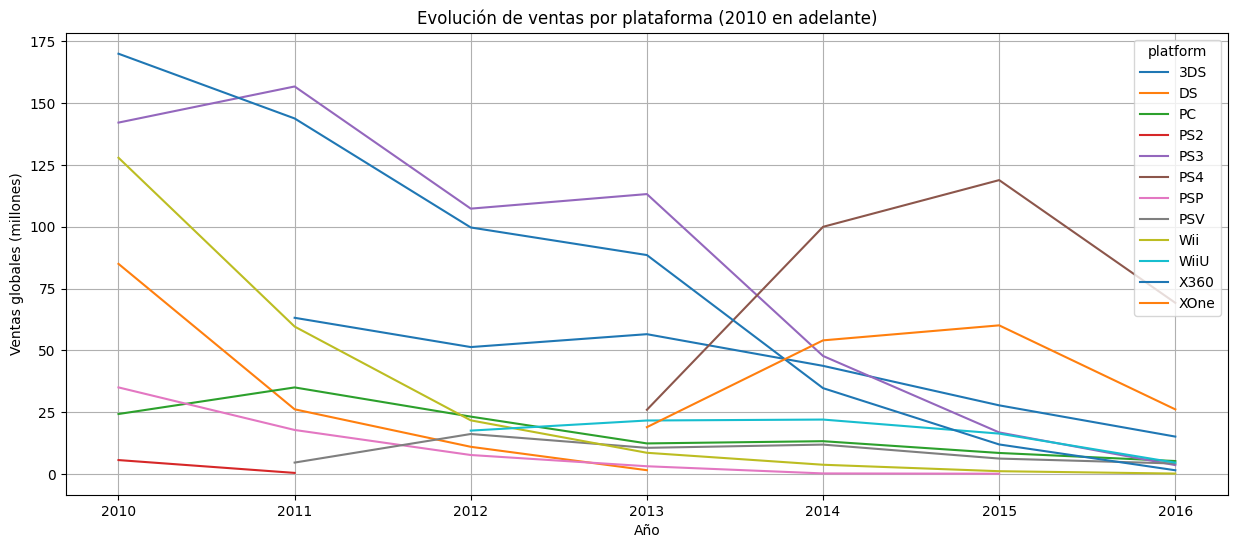

In [15]:
platform_year_sales = df_recent.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()

pivot = platform_year_sales.pivot(index='year_of_release', columns='platform', values='total_sales')

pivot.plot(figsize=(15,6))
plt.title('Evolución de ventas por plataforma (2010 en adelante)')
plt.xlabel('Año')
plt.ylabel('Ventas globales (millones)')
plt.grid(True)
plt.show()


Al analizar los datos desde 2010 en adelante, se observa que varias plataformas antiguas como DS, PSP, Wii, PS2, PS3 y Xbox 360 muestran una caída rápida en ventas y desaparecen del mercado entre 2013 y 2014, por lo que no aportan información válida para proyectar resultados hacia 2017. En contraste, las plataformas más recientes —principalmente PlayStation 4 y Xbox One— presentan un crecimiento sólido desde su lanzamiento en 2013, alcanzando sus mayores niveles de ventas en 2014 y 2015. La Nintendo 3DS mantiene un comportamiento estable durante todo el periodo, mientras que PC conserva ventas bajas pero constantes. A partir de esta tendencia, las plataformas líderes y relevantes para el futuro cercano son PS4, Xbox One, 3DS y PC, ya que son las únicas que continúan vigentes y con actividad significativa hacia 2016. Este grupo constituye la base adecuada para seleccionar plataformas potencialmente rentables y construir un modelo confiable para 2017.


## 3.6 diagrama de cajas

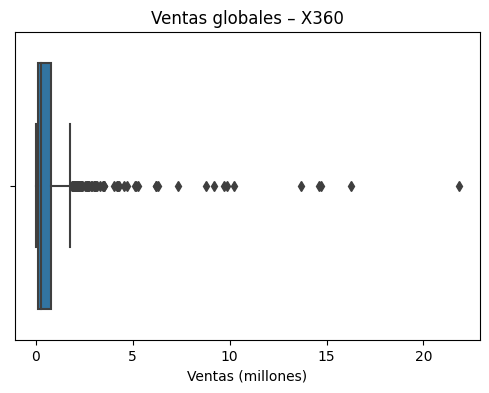

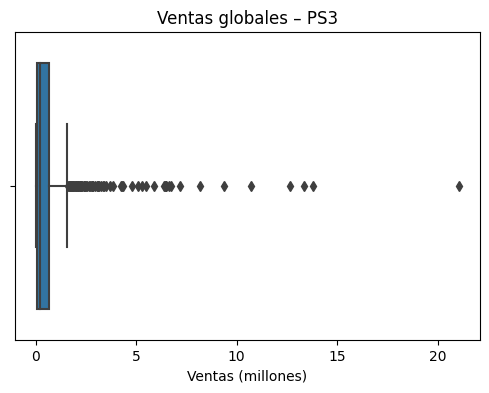

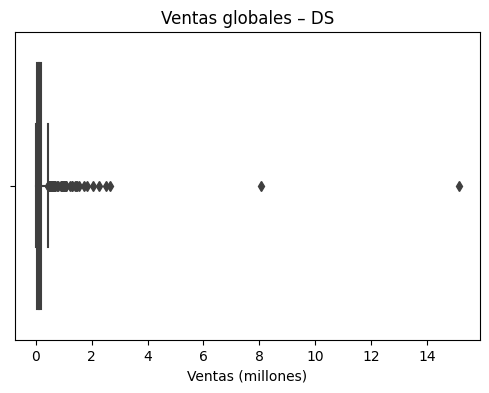

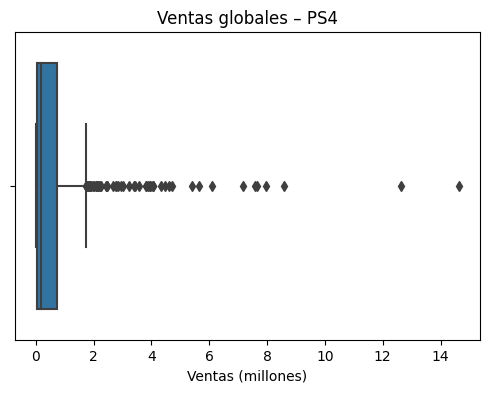

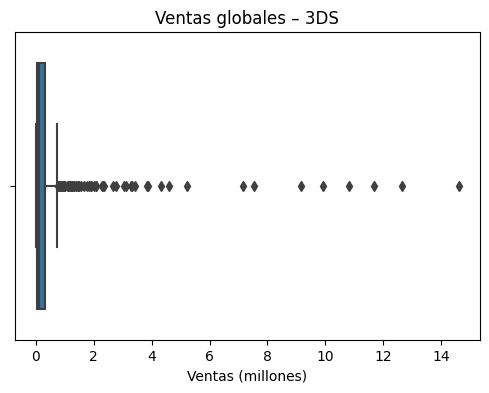

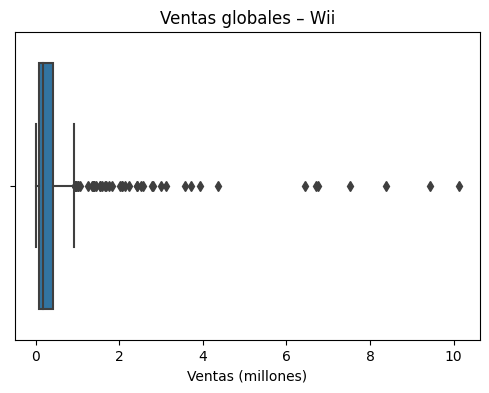

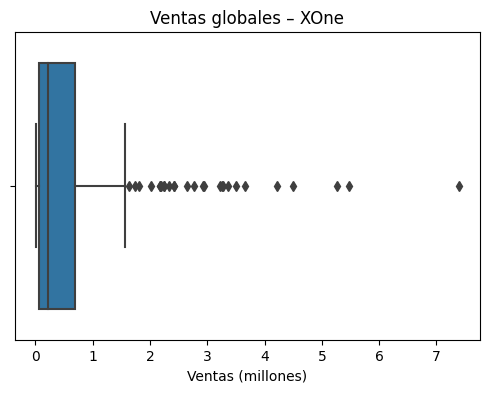

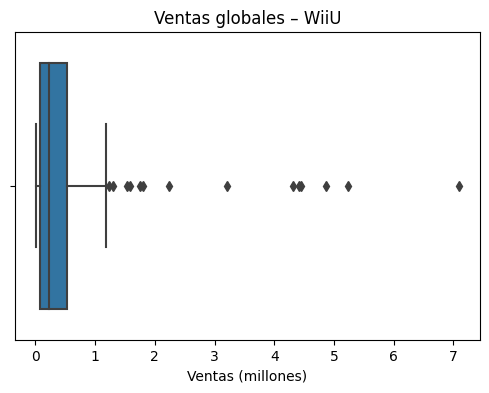

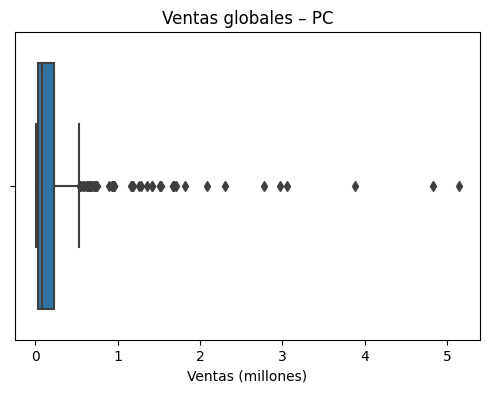

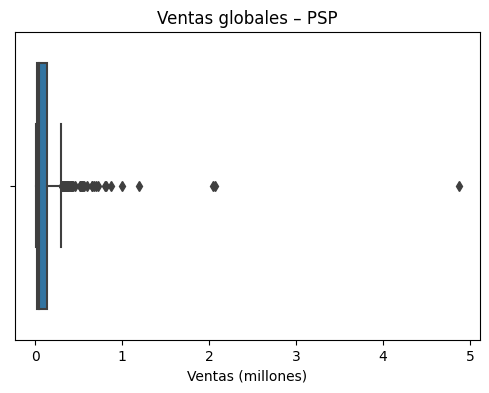

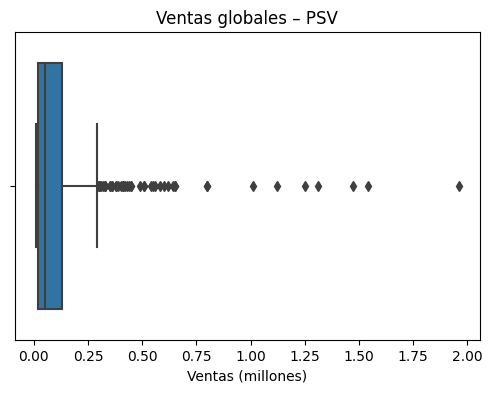

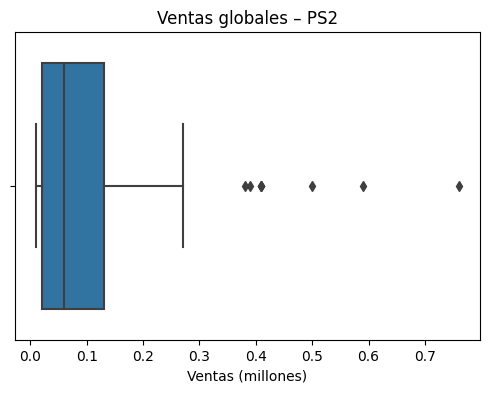

In [16]:
for plat in df_recent['platform'].unique():
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df_recent[df_recent['platform'] == plat], x='total_sales')
    plt.title(f'Ventas globales – {plat}')
    plt.xlabel('Ventas (millones)')
    plt.show()

<Figure size 1400x800 with 0 Axes>

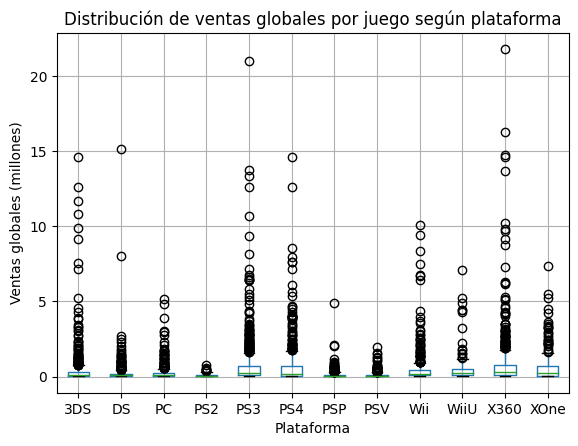

In [17]:
plt.figure(figsize=(14, 8))
df_recent.boxplot(column='total_sales', by='platform')
plt.title('Distribución de ventas globales por juego según plataforma')
plt.suptitle('')
plt.xlabel('Plataforma')
plt.ylabel('Ventas globales (millones)')
plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

En los diagramas de caja mostrados podemos observar que hay muchos valores atipicos que hacen que las cajas no se muestren correctamente, recomiendo removerlos con el parametro `showfliers = False`, te dejo el ejemplo en la celda de abajo
</div>


<Figure size 1400x800 with 0 Axes>

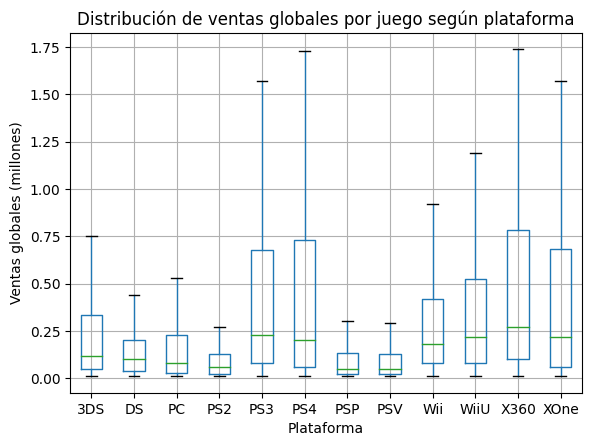

In [18]:
plt.figure(figsize=(14, 8))
df_recent.boxplot(column='total_sales', by='platform', showfliers = False)
plt.title('Distribución de ventas globales por juego según plataforma')
plt.suptitle('')
plt.xlabel('Plataforma')
plt.ylabel('Ventas globales (millones)')
plt.show()

A partir de 2010, varias plataformas comienzan a perder relevancia rápidamente: Wii, DS, PSP y PS2 muestran una caída constante en ventas hasta prácticamente desaparecer. PS3 y X360 mantienen ventas fuertes durante los primeros años, pero también entran en descenso conforme avanza la generación. Las plataformas que muestran un crecimiento real son PS4 y XOne, que aparecen alrededor de 2013 y comienzan a incrementar sus ventas de forma marcada. Entre ellas, PS4 destaca como la plataforma con mayor crecimiento y se convierte en la líder de ventas hacia 2015–2016. En general, el mercado transita de las consolas antiguas a la nueva generación, con PS4 como la plataforma más rentable del periodo analizado.

## 3.7 reseñas de usuarios y criticos afectan las ventas 

Correlación críticos: 0.40656790206178095
Correlación usuarios: -0.031957110204556376


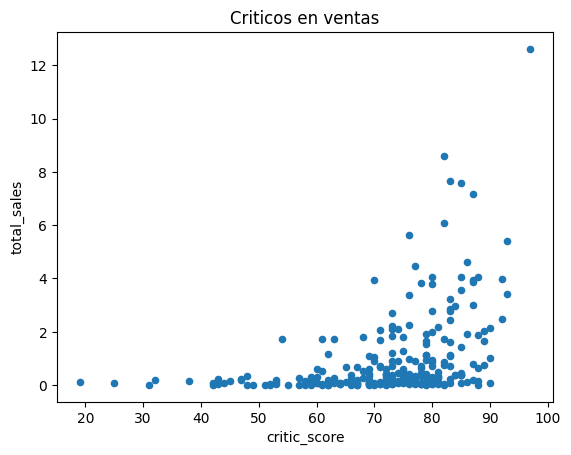

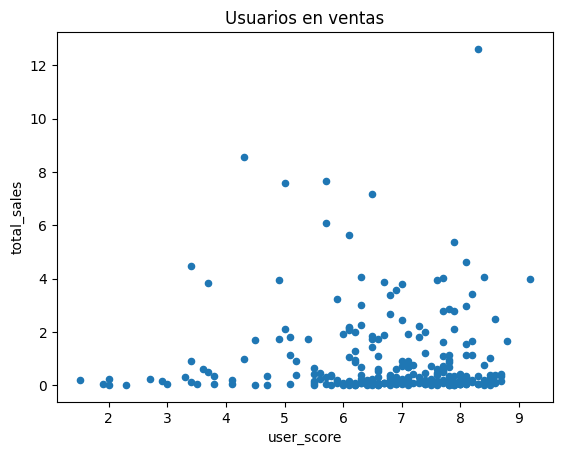

In [19]:

plat = df_games[df_games["platform"] == "PS4"]
plat.plot(kind="scatter", x="critic_score", y="total_sales", title="Criticos en ventas")

plat.plot(kind="scatter", x="user_score", y="total_sales", title="Usuarios en ventas")
print("Correlación críticos:", plat["critic_score"].corr(plat["total_sales"]))
print("Correlación usuarios:", plat["user_score"].corr(plat["total_sales"]))

En conjunto, los datos sugieren que las reseñas profesionales sí están asociadas con mayores ventas, mientras que las opiniones de los usuarios no predicen el éxito comercial. Esto puede deberse a que las calificaciones de usuarios suelen ser más subjetivas y muchas veces se escriben después de comprar el juego, por lo que no influyen directamente en la decisión inicial de compra

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de mostrar la correlación entre las ventas y las reseñas, como bien mencionas la correlación es debil-moderada por lo que no siempre las buenas reseñas van a implicar un gran numero de ventas
</div>


## 3.8 comparación de juegos

In [20]:
top_platforms = ['PS4', 'XOne']
df_top = df_games[df_games['platform'].isin(top_platforms)]

In [21]:


games_multiplatform = df_top['name'].value_counts()
games_multiplatform = games_multiplatform[games_multiplatform > 1]
games_multiplatform



Mark McMorris Infinite Air                    2
Titanfall 2                                   2
FIFA 16                                       2
Overwatch                                     2
The Wolf Among Us                             2
                                             ..
Homefront: The Revolution                     2
Transformers: Devastation                     2
Deus Ex: Mankind Divided                      2
Duke Nukem 3D: 20th Anniversary World Tour    2
Need for Speed (2015)                         2
Name: name, Length: 217, dtype: int64

In [22]:
games_multiplatform = df_top['name'].value_counts()
games_multiplatform = games_multiplatform[games_multiplatform > 1]

In [23]:
df_multi = df_top[df_top['name'].isin(games_multiplatform.index)]

comparacion = df_multi.groupby(['name', 'platform'])['total_sales'].sum().reset_index()


In [24]:
top2_by_platform = (
    comparacion.sort_values(['platform', 'total_sales'], ascending=[True, False])

    .groupby('platform')
    .head(2)
)



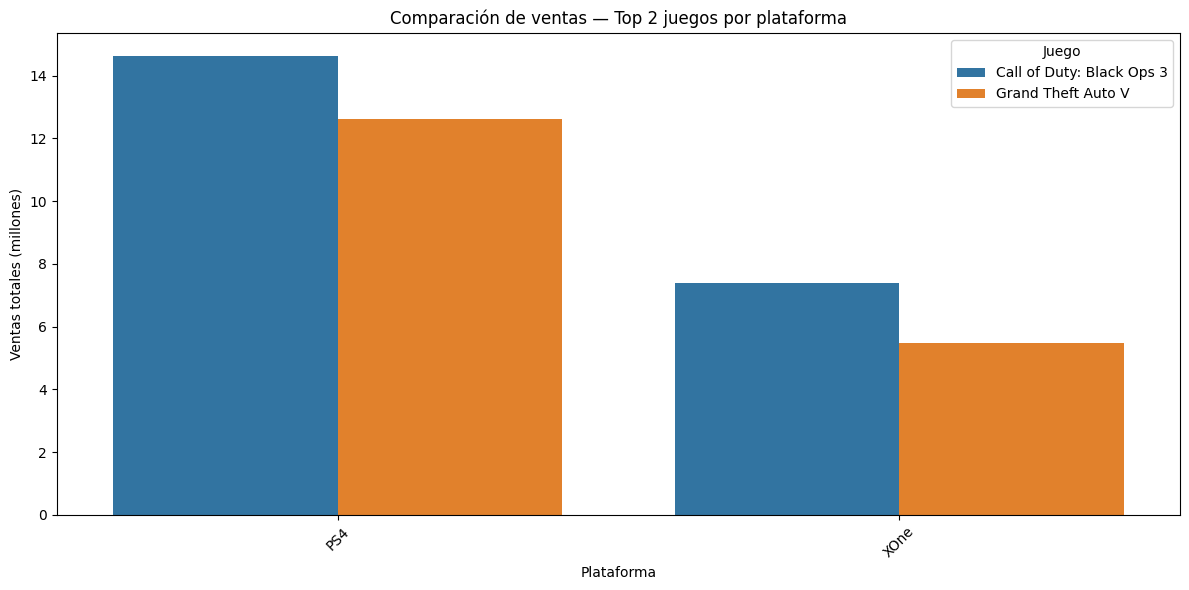

In [25]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top2_by_platform,
    x="platform",
    y="total_sales",
    hue="name"
)

plt.title("Comparación de ventas — Top 2 juegos por plataforma")
plt.ylabel("Ventas totales (millones)")
plt.xlabel("Plataforma")
plt.xticks(rotation=45)
plt.legend(title="Juego")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de mostrar los resultados, pdemos ver como los usuarios tienen preferencias por algunos videojuegos en ciertas plataformas, lo que nos ayuda a entender mejor al mercado
</div>


Los juegos multiplataforma seleccionados muestran mayores ventas en PS4 que en Xbox One. Este patrón se repite en ambos títulos analizados, lo que confirma que PS4 fue la plataforma con mayor demanda y mayor capacidad de conversión de ventas durante el periodo. Incluso cuando se trata de los mismos juegos, los usuarios de PS4 compraron más, lo que indica una base instalada más grande y un comportamiento de compra más activo.

## 3.8 juegos por genero

In [26]:
ventas_genre = df_games.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
ventas_genre

genre
Action          1744.17
Sports          1331.27
Shooter         1052.45
Role-Playing     934.56
Platform         827.77
Misc             802.51
Racing           728.67
Fighting         447.53
Simulation       389.97
Puzzle           242.57
Adventure        237.59
Strategy         174.23
Name: total_sales, dtype: float64

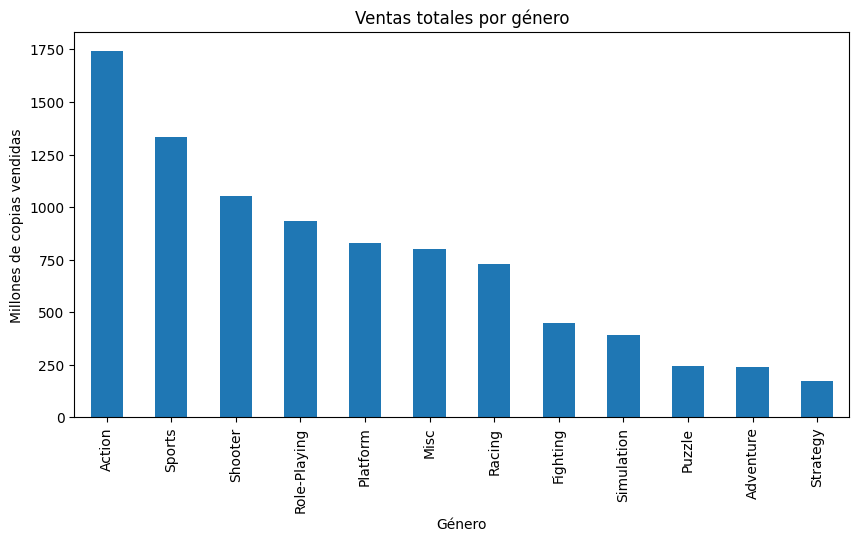

In [27]:
ventas_genre.plot(kind='bar', figsize=(10,5))
plt.title('Ventas totales por género')
plt.ylabel('Millones de copias vendidas')
plt.xlabel('Género')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de presentar los datos, podemos ver claramente cuales son los géneros preferidos de las personas, las observaciones que haces me parecen buenas también
</div>


De acuerdo al analisis de ventas por genero se puede determinar que tenemos una clara inclinación de los usuarios para los generos de accion deportes, disparos y juegos donde el usuario tiene un rol de juego

# 4 Perfil de usuario para cada region

## 4.1

In [28]:
top_platforms_NA = df_games.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
top_platforms_EU = df_games.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
top_platforms_JP = df_games.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

top_platforms_NA, top_platforms_EU, top_platforms_JP

(platform
 X360    602.47
 PS2     583.84
 Wii     496.90
 PS3     393.49
 DS      382.40
 Name: na_sales, dtype: float64,
 platform
 PS2     339.29
 PS3     330.29
 X360    270.76
 Wii     262.21
 PS      213.61
 Name: eu_sales, dtype: float64,
 platform
 DS      175.57
 PS      139.82
 PS2     139.20
 SNES    116.55
 3DS     100.67
 Name: jp_sales, dtype: float64)

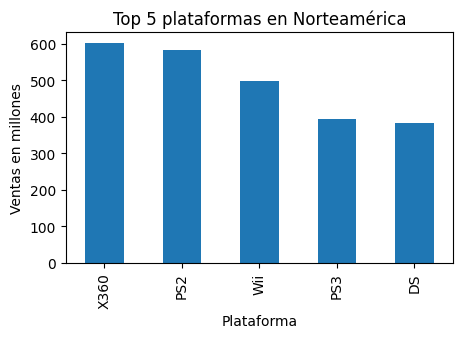

In [29]:
top_platforms_NA.plot(kind='bar', figsize=(5,3))
plt.title('Top 5 plataformas en Norteamérica')
plt.xlabel('Plataforma')
plt.ylabel('Ventas en millones')
plt.show()

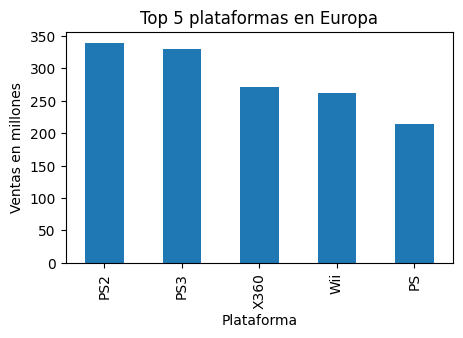

In [30]:
top_platforms_EU.plot(kind='bar', figsize=(5,3))
plt.title('Top 5 plataformas en Europa')
plt.xlabel('Plataforma')
plt.ylabel('Ventas en millones')
plt.show()

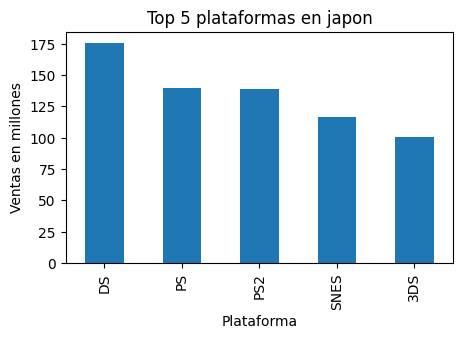

In [31]:
top_platforms_JP.plot(kind='bar', figsize=(5,3))
plt.title('Top 5 plataformas en japon')
plt.xlabel('Plataforma')
plt.ylabel('Ventas en millones')
plt.show()


En el analisis por region nos podemos dar cuenta que si varia mucho las ventas dependiendo de donde se revise ya que mientras que en estados unidos predomina la marca que desde mi punto de vista es insignia para ellos el xbox 360 y en segundo lugar esta el play 2 y en tercero el wii en europa predominan primero las consolas de playstation y despues las demas y por ultimo en japon predominan 100% las consolas japonesas como lo es nintendo DS y despues las de playstation. Por lo tanto se puede ver como claramente las marcas de las consolas se ven influenciadas por la cultura de cada region 

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Esta grafica nos cuenta cosas muy interesantes, Europa y Norteamerica con comportamientos algo similares mientras que Japón con una tendencia diferente en las ventas
</div>


## 4.2

In [32]:
top_genres_NA = df_games.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
top_genres_EU = df_games.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
top_genres_JP = df_games.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)

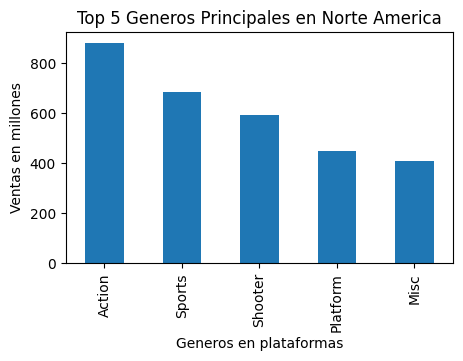

In [33]:
top_genres_NA.plot(kind = 'bar', figsize = (5,3))
plt.title('Top 5 Generos Principales en Norte America')
plt.ylabel('Ventas en millones')
plt.xlabel('Generos en plataformas')
plt.show()



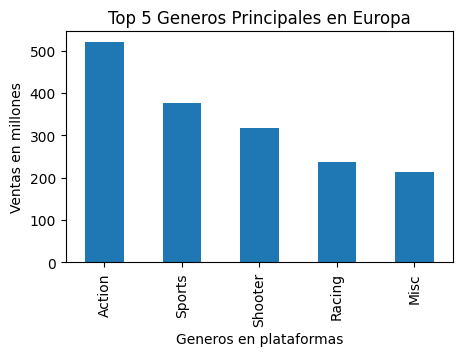

In [34]:

top_genres_EU.plot(kind = 'bar', figsize = (5,3))
plt.title('Top 5 Generos Principales en Europa')
plt.ylabel('Ventas en millones')
plt.xlabel('Generos en plataformas')
plt.show()



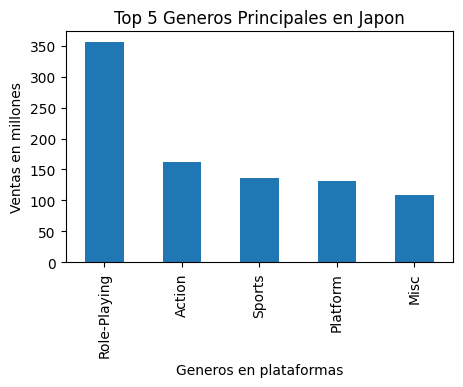

In [35]:
top_genres_JP.plot(kind = 'bar', figsize = (5,3))
plt.title('Top 5 Generos Principales en Japon')
plt.ylabel('Ventas en millones')
plt.xlabel('Generos en plataformas')
plt.show()

Aquí nuevamente vemos tendencias culturales ya que en los mercados occidentales como lo es norte america y europa vemos que los juegos que preominan en ventas numero uno son los de accion seguidos por los de deportes y disparos solo teniendo una variacion en en las ultimas dos variables siendo europa mas influenciado en carreras tala vez por la cultura apegada a la F1. Ya en el caso de los japoneses vemos que hay una total tendendencia a juegos donde no se incluye la violencia y optan mas por el role playing accion y deportes 

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!

Una vez más el mercado japonés marcando una tendencia única
</div>


## 4.3

In [36]:

esrb_na = df_games.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
esrb_eu = df_games.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
esrb_jp = df_games.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)


<function matplotlib.pyplot.show(close=None, block=None)>

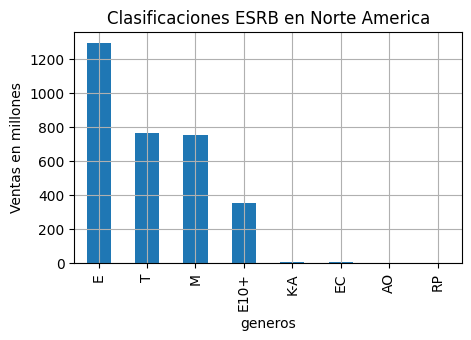

In [37]:


esrb_na.plot(kind = 'bar',figsize = (5,3))
plt.title('Clasificaciones ESRB en Norte America')
plt.ylabel('Ventas en millones')
plt.xlabel('generos')
plt.grid(True)
plt.show



<function matplotlib.pyplot.show(close=None, block=None)>

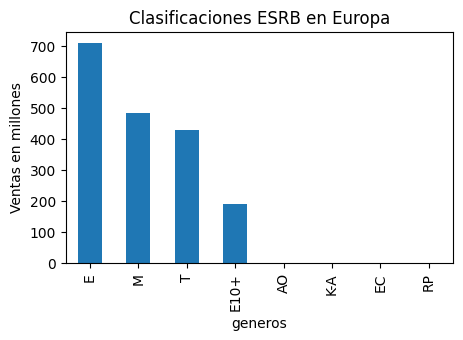

In [38]:
esrb_eu.plot(kind = 'bar',figsize = (5,3))
plt.title('Clasificaciones ESRB en Europa')
plt.ylabel('Ventas en millones')
plt.xlabel('generos')
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

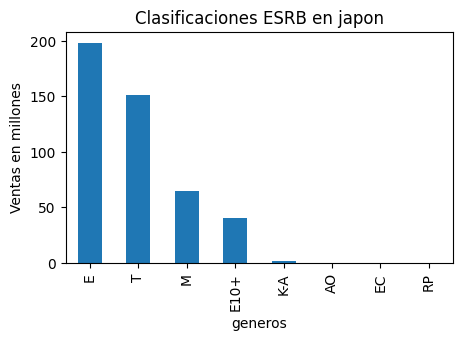

In [39]:
esrb_jp.plot(kind = 'bar',figsize = (5,3))
plt.title('Clasificaciones ESRB en japon')
plt.ylabel('Ventas en millones')
plt.xlabel('generos')
plt.show


Los juegos con clasificación “E” son los más rentables a nivel global, pero Norteamérica y Europa consumen más juegos T y M que Japón, demostrando diferencias culturales claras en la demanda por tipo de contenido.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!

Podemos ver las preferencias/diferencias de las regiones ya que se ha utilizado una manera clara de mostrar la información
</div>


# 5. Prueba las siguientes hipótesis:

## 5.1 calificaciones promedio de los usuarios xbox one y pc son las mismas

In [40]:
alpha = 0.05
xone_scores = df_games[df_games['platform'] == 'XOne']['user_score']
pc_scores   = df_games[df_games['platform'] == 'PC']['user_score']
t_stat, p_value = st.ttest_ind(xone_scores, pc_scores, equal_var=False, nan_policy = 'omit')
#use el nan_policy que fredy nos enseño en el webinar super buena herramienta 
print("Hipotesis 1: Xbox One vs PC")
print("t =", t_stat)
print("p =", p_value)
if p_value < alpha:
    print("Rechazamos hipotesis nula: Las calificaciones promedio NO son iguales.\n")
else:
    print("No se rechaza la hipotesis nula: No hay evidencia de diferencia significativa.\n")

Hipotesis 1: Xbox One vs PC
t = -4.653422798410772
p = 4.935072360183565e-06
Rechazamos hipotesis nula: Las calificaciones promedio NO son iguales.



## 5.2 Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

In [41]:
alpha = 0.05
action_scores = df_games[df_games['genre'] == 'Action']['user_score']
sports_scores = df_games[df_games['genre'] == 'Sports']['user_score']
t_stat2, p_value2 = st.ttest_ind(action_scores, sports_scores, equal_var=False,nan_policy = 'omit')

print("Hipotesis 2: Acción vs Deportes")
print("t =", t_stat2)
print("p =", p_value2)
if p_value2 < alpha:
    print("rechazamos hipotesis nula: Hay diferencia significativa entre los géneros.\n")
else:
    print("no se rechaza la hipotesis nula: No hay evidencia de diferencia entre los géneros.\n")

Hipotesis 2: Acción vs Deportes
t = 1.5774679163335246
p = 0.11483818791498648
no se rechaza la hipotesis nula: No hay evidencia de diferencia entre los géneros.



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />


El planteamiento de la hipótesis me parece correcto en ambos casos, bien hecho!
</div>


## 5. Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

Para cada comparación definí primero la hipótesis nula porque es el punto de partida en cualquier prueba estadística. La hipótesis nula siempre plantea que no hay diferencia entre los grupos, en este caso entre las plataformas o entre los géneros. La hipótesis alternativa plantea lo contrario: que sí existe una diferencia en las calificaciones promedio.
Por eso, para Xbox One vs PC y para Acción vs Deportes, la hipotesis nula afirma que las calificaciones promedio son iguales mientras que la alternativa dice que son diferentes.

## 5.4 Qué criterio utilizaste para probar las hipótesis y por qué.

Para evaluar las hipótesis utilicé una prueba t para muestras independientes porque estoy comparando los promedios de dos grupos distintos y la variable es numérica. Elegi un nivel de significancia α = 0.05, que es el que en la teoria nos han dicho que es el estandar y el criterio fue comparar el valor p contra ese alfa, entonces si p es menor a 0.05, rechazo la hipotesis nula pero si p es mayor no se rechaza, por lo tanto este criterio me permite decidir objetivamente si los datos muestran una diferencia real entre los grupos o si la diferencia se puede deber al azar

# 6. CONCLUSIÓN GENERAL

En este proyecto entendí mejor cómo se comportan las ventas de videojuegos en distintas regiones y qué factores influyen en ellas. Vi que los géneros más rentables suelen ser Acción, Shooter y Deportes, mientras que otros como Puzzle o Adventure venden mucho menos

También noté que cada región tiene gustos diferentes. En Norteamérica y Europa destacan casi las mismas plataformas, pero en Japón las preferencias cambian mucho y se enfocan más en consolas de Nintendo. Lo mismo pasa con los géneros. Japón prefiere RPG, mientras que NA y EU se inclinan por Acción y Shooter. Las clasificaciones ESRB también influyen porque solo E, T y M tienen ventas fuertes, las demás prácticamente no venden.

En las pruebas estadísticas descubrí que las calificaciones de usuarios sí son diferentes entre Xbox One y PC, pero entre los géneros Acción y Deportes no hubo diferencia significativa.
En general este proyecto me ayudó a entender qué se vende más, cómo cambian los gustos según la región y qué cosas realmente afectan el comportamiento de los jugadores y del mercado

## Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, las observaciones que has hecho durante todo el ejercicio me han parecido bastante buenas, son un gran apoyo a la hora de revisar el proyecto ya que me dan a entender que el tema te ha quedado claro y has podido avanzar correctamente.

    
Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>


In [ ]:
<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen bastante detalladas
- Las graficas utilizadas me parecen del tipo correcto
- El proyecto esta ordenado y limpio
    
</div>
